# Linnaeus University
## Introduction to Machine learning, 25VT-2DV516
## Assignment 1

**Name:** ## Alen Smlatic ## 

**Email:** ## as228vx@student.lnu.se ##

## Introduction

In this assignment you will handle four exercises related to the k-Nearest Neighbors algorithm.
The main purpose is to get you up and running using Python, NumPy and Matplotlib. 
The library Scipy will be used specifically in Exercise 3, part 2.

## Submission Instructions

All exercises are individual. We expect you to submit a zip file with this notebook with your solutions and the MachineLearning.py with the models implemented. 
You must normalize your data before doing anything with your data.
When grading your assignments we will in addition to functionality also take into account code quality. 
We expect well structured and efficient solutions. 
Finally, keep all your files in a single folder named as username_A1 and submit a zipped version of this folder.

### Exercise 1: Models implementation and testing (All Mandatory)

1. Implement all the methods in the abstract classes **KNNRegressionModel** and **KNNClassificationModel** in the MachineLearningModel.py file. 
As the names suggest, you must implement the Regression (slide 30) and Classification (slide 24) versions of the KNN algorithm and you must follow the algorithms stated in the slides. 
* Both models must use the Euclidean distance as the distance function (*Tip: Code smart by implementing an auxiliary method _euclidian_distance() in the MachineLearningModel.py file*).
* The evaluate() function for the **KNNRegressionModel** must implement the Mean Squared Error (MSE)
* The evaluate() function for the **KNNClassificationModel** must count the number of correct predictions.

2. Use the *Polynomial200.csv* dataset to show that all your methods for the **KNNRegressionModel** is working as expected. You must produce a similar figure to the one in slide 31. Instructions to produce the figure are present in the slide. You must show the effects of using k = 3, 5, 7 and 9 and discuss your findings on the figure produced.

**Discuss your findings for this question below**

----- Your answer here -----


k=3, MSE=16.438
k=5, MSE=20.105
k=7, MSE=21.963
k=9, MSE=22.304


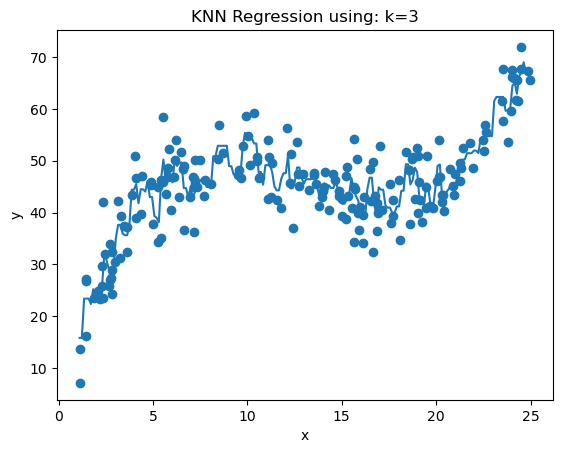

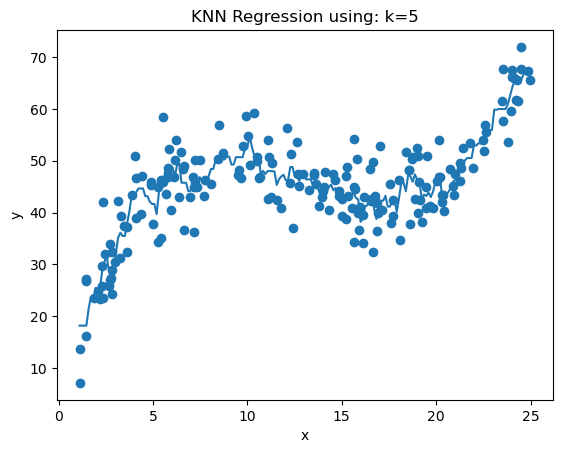

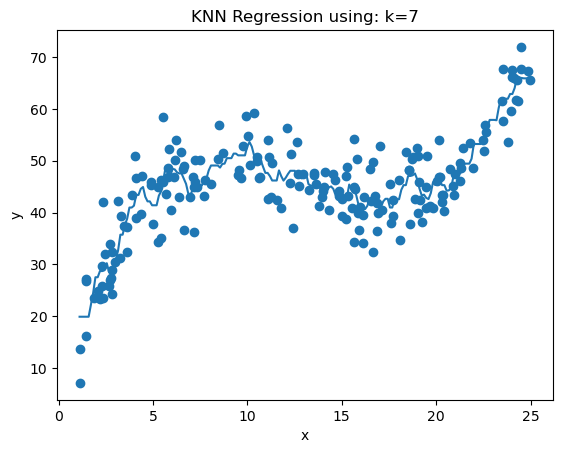

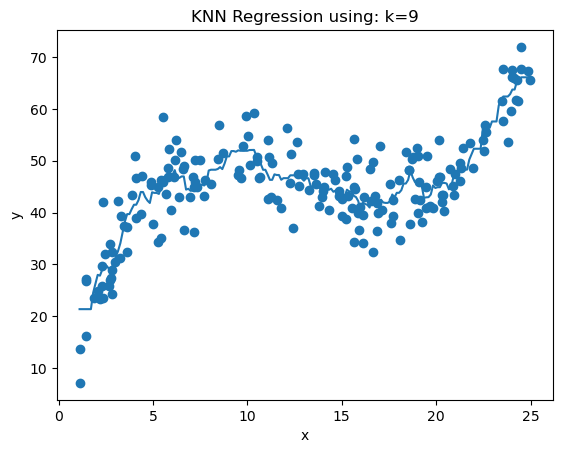

In [3]:
### Your code here ###
from MachineLearningModel import KNNRegressionModel
import numpy as np
import matplotlib.pyplot as plt 

dataset = np.loadtxt("Polynomial200.csv", delimiter=",", skiprows=1)

X = dataset[:, 0]
y = dataset[:, 1]
X_test = np.linspace(X.min(), X.max(), 200)
k = np.array([3, 5, 7, 9])

for k_values in k:
    plt.figure()
    model = KNNRegressionModel(k_values)
    model.fit(X, y)

    y_train_pred = model.predict(X)
    mse = model.evaluate(y, y_train_pred)
    print(f"k={k_values}, MSE={mse:.3f}")

    y_pred = model.predict(X_test)
    plt.scatter(X, y)
    plt.plot(X_test, y_pred)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"KNN Regression using: " f"k={k_values}")


    """
    On the different plots we can see how the model changes based on the value of k. The datapoints stay the same, but the predicted line is different.

    We can see that k = 3 has the most overfitting, because the line follows the data very closely and its very noisy. 
    As k increases the line becomes smoother and less affected by the noise. As we see the MSE we can tell that k=3 has the smallest MSE value. However, the training MSE may be misleading and the model should ideally be evaluated using test error.

    For k = 9 the line is the smoothest but it starts to miss some patterns in the data which means it is underfitting.
    Overall,smaller k leads to overfitting and larger k leads to smoother predictions.

    """
   



3. Use the *IrisDataset.csv* dataset to show that all your methods for the **KNNClassificationModel** is working as expected. You must produce a similar figure to the one in slide 28. Instructions on how to produce the figure are given in the slide. You must choose 2 input variables only to produce the figure (they do not need to match the figure in the slide). You must show the effects of using k = 3, 5, 7, and 9 and discuss the figure produced.

**Tips**

* Check the function *np.meshgrid* from numpy to create the samples.
* Check the function *plt.contourf* for generating the countours. 
* There are many tutorials online to produce this figure. Find one that most suits you.

**Discuss your findings for this question below**

----- Your answer here -----

C:\Users\alens\AppData\Local\Temp\ipykernel_21432\2300338858.py:8: UserWarning: Input line 152 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("IrisDataset.csv", delimiter=",", skiprows=1, dtype=str)


'\nWhen comparing these 4 plots we can see that k = 3 is overfitting since the decision boundary is more noisy and closely follows the training points. This makes the model sensitive to noise and small variations in the dataset.\nAs the k value increases to 5 and 7 we can see that the decision follows the training  points which reduces the noise and improves generalization and the model considers more neighboring points.\n\nFor k = 9 the boundary is the smoothest but its starts to oversimplifying the data, this indicates underfitting. Where the model may miss important pattern between classes. \nBut overall smaller values of k lead to high variance and overfitting, while larger k values increases bias and can causes underfitting. In our case k=5 or k=7 gives a good balance between accuracy and generalization.\n\n'

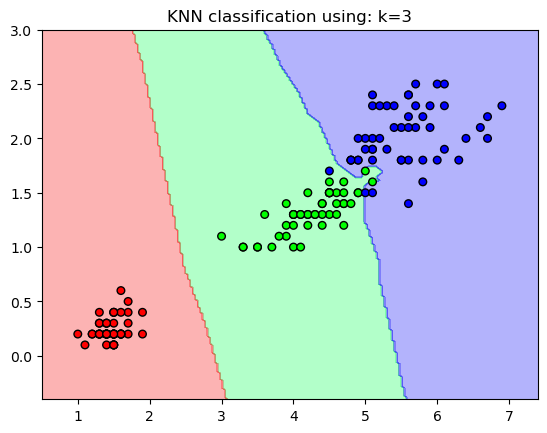

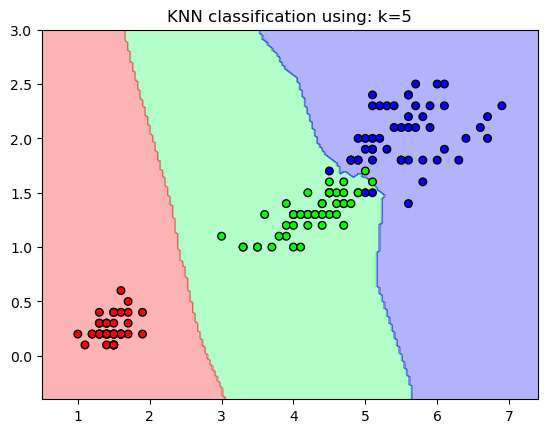

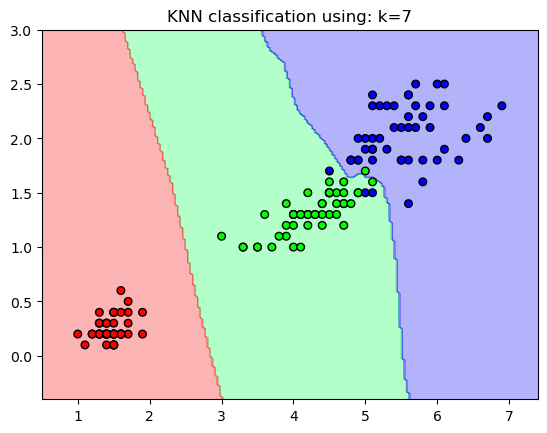

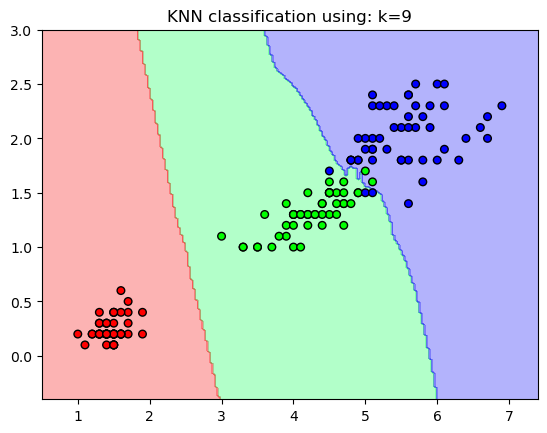

In [32]:
### Your code here ###
from MachineLearningModel import KNNClassificationModel
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


data = np.loadtxt("IrisDataset.csv", delimiter=",", skiprows=1, dtype=str)
X = data[:, [2,3]].astype(float) # this will give us PetalLengthCm and PetalWidthCm
y = data[:, -1] #This is what we want to predict (yi) in this case its the species of the flower.
k = [3, 5, 7, 9] #K-values


#Convert labels from String into int
y[y == "Iris-setosa"] = 0
y[y == "Iris-versicolor"] = 1
y[y == "Iris-virginica"] = 2
y  = y.astype(int)


  

for k_values in k:
    model = KNNClassificationModel(k_values)
    model.fit(X, y)
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5 
    y_min, y_max = X[:, 1].min()-0.5 , X[:, 1].max() + 0.5 
    x_values = np.linspace(x_min, x_max, 200)
    y_values = np.linspace(y_min, y_max, 200)
    xx, yy = np.meshgrid(x_values, y_values)
    x_grid = np.array(list(zip(xx.ravel(), yy.ravel())))
    zz = model.predict(x_grid)
    zz = zz.reshape(xx.shape)
    
    
    color_grid = ListedColormap(["#F80505AE", "#03FF4F97", "#0606F7AE"])
    color_points  = ListedColormap(["#FF0000", "#00FF00", "#0000FF"])
    
    plt.figure()
    plt.contourf(xx, yy, zz, cmap=color_grid, alpha=0.3)
   
    plt.scatter(X[:, 0], X[:, 1],c=y,cmap=color_points, edgecolors="k", s=30)
    plt.xlim(xx.min(), xx.max()) # set limits of x-axis to match the grid range
    plt.ylim(yy.min(), yy.max()) #set limits of y-axis to match the grid range
    plt.title(f"KNN classification using: " f"k={k_values}")



"""
When comparing these 4 plots we can see that k = 3 is overfitting since the decision boundary is more noisy and closely follows the training points. This makes the model sensitive to noise and small variations in the dataset.
As the k value increases to 5 and 7 we can see that the decision follows the training  points which reduces the noise and improves generalization and the model considers more neighboring points.

For k = 9 the boundary is the smoothest but its starts to oversimplifying the data, this indicates underfitting. Where the model may miss important pattern between classes. 
But overall smaller values of k lead to high variance and overfitting, while larger k values increases bias and can causes underfitting. In our case k=5 or k=7 gives a good balance between accuracy and generalization.

"""








### Exercise 2: KNN Regression (Mandatory)

1. (Mandatory) Create a procedure to repeat 10 times the following strategy.
* Use the values for k = 3, 5, 7, 9, 11, 13 and 15.
* Split your dataset randomly into 80% for training, and 20% testing. Use 10 different seeds for splitting the data.
* Evaluate (MSE implemented in your class) your **KNNRegressionModel** for each k in the **test set** and store the result. 
* Plot a barchart with these results.

Which k gives the best regression? Motivate your answer!

**Discuss your findings for this question below**

----- Your answer here -----

Min MSE: 25.5514 result of 13


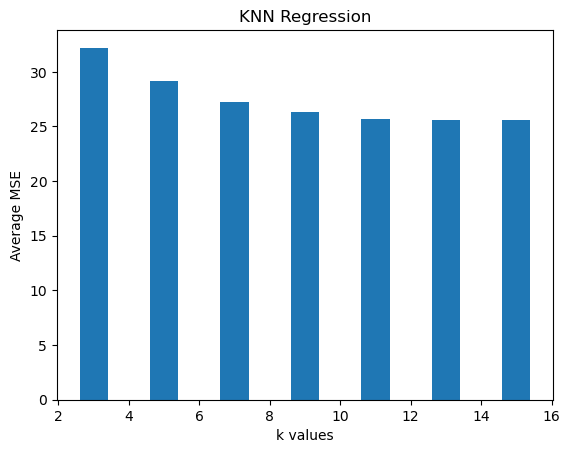

In [ ]:
### Your code here ###
from MachineLearningModel import KNNRegressionModel
import numpy as np
import matplotlib.pyplot as plt


dataset = np.loadtxt("Polynomial200.csv", delimiter="," ,skiprows=1)
X = dataset[:, 0]
y = dataset[:, 1]
k = [3, 5, 7, 9, 11, 13, 15]
store_res = {k_values: [] for k_values in k} # groups mse values by k





for seed in range(10):
    length = len(X)
   
    np.random.seed(seed)
    indices = np.arange(length)
    np.random.shuffle(indices)
   
    X_shuffle = X[indices]
    y_shuffle = y[indices]
    
    split_dataset = int(0.8 * length)
    
    X_train =  X_shuffle[:split_dataset] # -> 80% of dataset
    y_train = y_shuffle[:split_dataset]    

    X_test = X_shuffle[split_dataset:] # -> the remaining 20%
    y_test = y_shuffle[split_dataset:]

    for k_value in k:
        model = KNNRegressionModel(k_value)
        model.fit(X_train, y_train)
        y_hat = model.predict(X_test)
        mse = model.evaluate(y_test, y_hat)
        store_res[k_value].append(mse)
    
    
avg_mse = {}
for  k_value in k:
    avg_mse[k_value] = np.mean(store_res[k_value])


plt.figure()
plt.bar(avg_mse.keys(), avg_mse.values())
plt.xlabel("k values")
plt.ylabel("Average MSE")
plt.title("KNN Regression")
best_k = min(avg_mse, key=avg_mse.get)
print("Min MSE:", round(np.min(list(avg_mse.values())), 4), "result of " + f"{best_k}")



### Exercise 3: KNN Classification (1 Mandatory , 1 Non-Mandatory)

1. **(Mandatory)** Using the **IrisDataset.csv**, find the best combination of two features that produces the best model using **KNNClassificationModel**.
* You must try all combinations of two features, and for k = 3, 5, 7, and 9.
*   

**Discuss your findings for this question below**

----- Your answer here -----


C:\Users\alens\AppData\Local\Temp\ipykernel_13556\682424098.py:8: UserWarning: Input line 152 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  dataset = np.loadtxt("IrisDataset.csv", delimiter=",", skiprows=1, dtype=str)


best accuracy: 147
best pair: (2, 3)
best k: 3


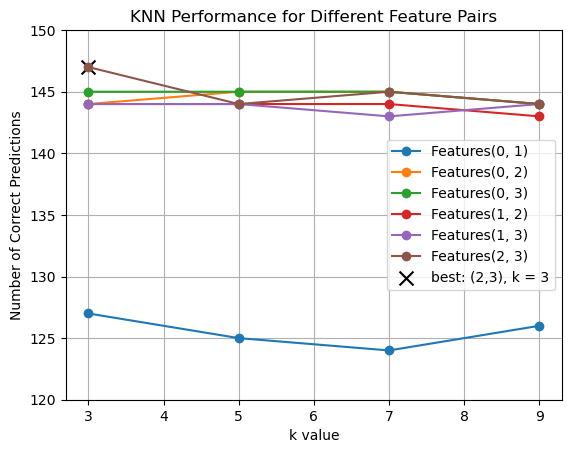

In [23]:
### Your code here ###
from MachineLearningModel import KNNClassificationModel
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations  # let us use python in-build function to find the  combination so we do not need to code our own.


dataset = np.loadtxt("IrisDataset.csv", delimiter=",", skiprows=1, dtype=str)
k = [3,5,7,9]
feature = [0,1,2,3]
result = []

y = dataset[:, -1]
y[y == "Iris-setosa"] = 0
y[y == "Iris-versicolor"] = 1
y[y == "Iris-virginica"] = 2
y = y.astype(int)

for pair in combinations(feature, 2):
    X = dataset[:, pair].astype(float)

    for k_value in k:
        model = KNNClassificationModel(k_value)
        model.fit(X, y)
        y_hat = model.predict(X)
        accuracy = model.evaluate(y, y_hat)
        result.append((pair, k_value, accuracy))

best = result[0]

for res in result:
    if res[2] > best[2]:
        best = res

plot = {}
for pair, k_value, accuracy in result:
    if pair not in plot:
        plot[pair] = {}
        plot[pair]["k"] = []
        plot[pair]["accuracy"] = []


    plot[pair]["k"].append(k_value)
    plot[pair]["accuracy"].append(accuracy)



for pair in plot:
    plt.plot(plot[pair]["k"],plot[pair]["accuracy"], marker="o", label=f"Features{pair}")
plt.ylim(120, 150)
plt.scatter(best[1], best[2], s = 100, marker="x", color="black", label="best: (2,3), k = 3")
plt.xlabel("k value")
plt.ylabel("Number of Correct Predictions")
plt.title("KNN Performance for Different Feature Pairs")
plt.grid()
plt.legend()


print("best accuracy:", best[2])
print("best pair:", best[0])
print("best k:", best[1])







2. **(Non-mandatory)** Implement a new Class called **FastKNNClassificationModel**. This method should be faster than your regular implementation. This can be done by using a faster data structure to look for the closest neighbors faster. In this assignment, you must build the KDTree with the the training data and then search for the neighbors using it.

* You must use this implementation of KDTree from Scipy. https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.KDTree.html
* The methods needed for your implementation are only the *constructor* (to build the KDTree) and the method *query* to find the k-neighbors.
* You must design an experiment using the **IrisDataset.csv** with **all features** to show that your new implementation is faster than your implementation of **KNNClassificationModel**.
* For example, you can measure the time using of each prediction, for each classifier, and plot the average time to give a decision for entries. Also, measure how this would increase/decrease with the increment of the input parameter *k*. 
* Use a plot(s) from matplotlib to support your answer.

**Discuss your findings for this question below**

----- Your answer here -----

In [ ]:
### Your code here ###

## Exercise 4: MNIST k-NN classification (Non-mandatory)

In this final exercise, we will use k-NN for classifying handwritten digits using the very famous MNIST dataset. Input to the algorithm is an image (28x28 pixel) with a handwritten digit (0-9) and the output should be a classification 0-9. The dataset and a description of it is available at http://yann.lecun.com/exdb/mnist/. Google MNIST Python to learn how to access it. The objective is to use your k-NN classifier to perform as good as possible on recognizing handwritten images. Describe your effort and what you found out to be the best k to lower the test error. The complete dataset has 60,000 digits for training and 10,000 digits for testing. Hence the computations might be heavy, so start of by a smaller subset rather than using the entire dataset. The final testing should (if possible) be done for the full test set but we will accept solutions that use "only" 10,000 digits for training and 1,000 digits for testing.
The description of this exercise is deliberately vague as you are supposed to, on your own, find a suitable way to solve this problem in detail. This is why it is important that you document your effort and progress in your report. **You must use your implementations of KNN for classification. If you successfully finished Exercise 3, part 2, it is advisable to use your FastKNNClassificationModel**

In [ ]:
### Your code here ###